In [1]:
#Import Pandas, SQLite3, Matplotlib, and Plotly libraries 

import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
#Import dataset and preview the data 

df = pd.read_csv("HousePrices_dataset.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,02-05-2014 00:00,313000.0,3,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,02-05-2014 00:00,2384000.0,5,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,02-05-2014 00:00,342000.0,3,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,02-05-2014 00:00,420000.0,3,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,02-05-2014 00:00,550000.0,4,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [ ]:
#Format/clean column names

df.columns = df.columns.str.strip().str.lower()

In [ ]:
print(df.columns)

In [10]:
#Change price column to price in thousands

df["price_in_thousands"] = df["price"]/1000

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country,price_in_millions,price_in_thousands
0,02-05-2014 00:00,313000.0,3,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA,0.313,313.0
1,02-05-2014 00:00,2384000.0,5,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA,2.384,2384.0
2,02-05-2014 00:00,342000.0,3,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA,0.342,342.0
3,02-05-2014 00:00,420000.0,3,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA,0.420,420.0
4,02-05-2014 00:00,550000.0,4,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA,0.550,550.0


In [11]:
df.describe().round(2)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_in_millions,price_in_thousands
count,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00
mean,551962.99,3.40,2.16,2139.35,14852.52,1.51,0.01,0.24,3.45,1827.27,312.08,1970.79,808.61,0.55,551.96
std,563834.70,0.91,0.78,963.21,35884.44,0.54,0.08,0.78,0.68,862.17,464.14,29.73,979.41,0.56,563.83
min,0.00,0.00,0.00,370.00,638.00,1.00,0.00,0.00,1.00,370.00,0.00,1900.00,0.00,0.00,0.00
25%,322875.00,3.00,1.75,1460.00,5000.75,1.00,0.00,0.00,3.00,1190.00,0.00,1951.00,0.00,0.32,322.88
50%,460943.46,3.00,2.25,1980.00,7683.00,1.50,0.00,0.00,3.00,1590.00,0.00,1976.00,0.00,0.46,460.94
75%,654962.50,4.00,2.50,2620.00,11001.25,2.00,0.00,0.00,4.00,2300.00,610.00,1997.00,1999.00,0.65,654.96
max,26590000.00,9.00,8.00,13540.00,1074218.00,3.50,1.00,4.00,5.00,9410.00,4820.00,2014.00,2014.00,26.59,26590.00


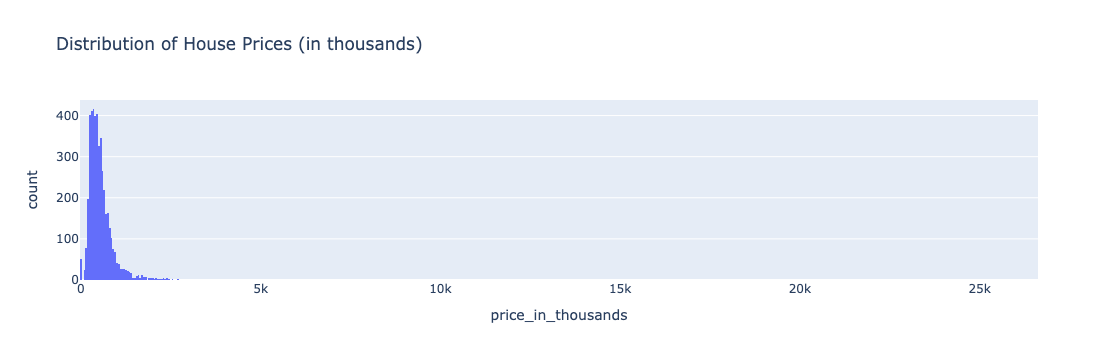

In [12]:
#Visualization 1 - Histogram

fig = px.histogram(
    df,
    x="price_in_thousands",
    title="Distribution of House Prices (in thousands)"
)

fig.show()

Analysis of Histogram: 
The distribution of house prices is heavily right-skewed, with most homes concentrated between $300K and $650K and a median price of about $461K. A small number of high-end outliers — 47 homes priced above $2M - stretch the x-axis and compress the bulk of the distribution, making the histogram hard to read in its current form. Additionally, 49 records show a price of $0, which likely reflect missing or invalid entries rather than actual sales and should be excluded before further analysis. To improve readability, I'd recommend capping the x-axis at $2M to focus on the primary distribution and note the outliers separately. 

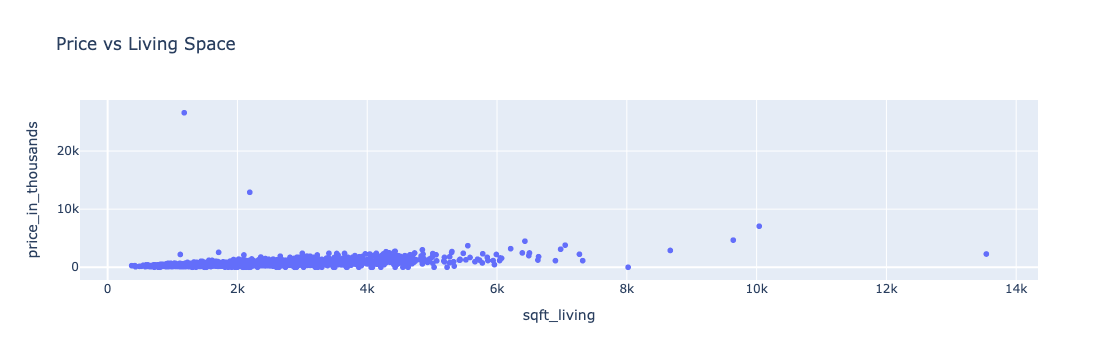

In [13]:
#Visualization 2 - Scatter plot

fig = px.scatter(
    df,
    x="sqft_living",
    y="price_in_thousands",
    title="Price vs Living Space",
    hover_data=["bedrooms", "bathrooms"]
)

fig.show()

Analysis of Scatterplot:
The scatter plot shows a general positive trend — larger homes tend to sell for more — but the relationship is loose rather than tight, with a wide spread of prices even among homes of similar size. Two points stand out as likely data errors: a $26.6M home listed at only 1,180 sqft and a $12.9M home at 2,190 sqft, both far smaller than what those prices would suggest.

In [20]:
#Create a new a database connection

conn = sqlite3.connect("house_prices.db")
c = conn.cursor()

#df.head()
#df.info()

In [21]:
#Drop the table if it already exists and create the HousePrices table

c.execute("DROP TABLE IF EXISTS HousePrices")
 
c.execute("""
CREATE TABLE HousePrices (
    date TEXT,
    price FLOAT,
    yr_built INTEGER,
    yr_renovated INTEGER
)
""")
conn.commit()

In [22]:
#Inserting the data

for idx, row in df.iterrows():
    c.execute("""
    INSERT INTO HousePrices (date, price, yr_built, yr_renovated)
    VALUES (?, ?, ?, ?)
    """,
    (str(row["date"]), row["price"], row["yr_built"], row["yr_renovated"]))

conn.commit()

In [23]:
#Double checking that the data has been inserted into the table correctly

sql_dbl_check = pd.read_sql("SELECT * FROM HousePrices LIMIT 10", conn)
print(sql_dbl_check)

               date      price  yr_built  yr_renovated
0  02-05-2014 00:00   313000.0      1955          2005
1  02-05-2014 00:00  2384000.0      1921             0
2  02-05-2014 00:00   342000.0      1966             0
3  02-05-2014 00:00   420000.0      1963             0
4  02-05-2014 00:00   550000.0      1976          1992
5  02-05-2014 00:00   490000.0      1938          1994
6  02-05-2014 00:00   335000.0      1976             0
7  02-05-2014 00:00   482000.0      1989             0
8  02-05-2014 00:00   452500.0      1985             0
9  02-05-2014 00:00   640000.0      1945          2010
